# **IT Service Ticket Classification**

In [ ]:
#Basic Libraries
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)  # To display full text in DataFrame

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sentence_transformers import SentenceTransformer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

#Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score, StratifiedKFold

#Evaluation
from sklearn.metrics import classification_report, confusion_matrix

### Data Load

In [3]:
data = pd.read_csv('Data/all_tickets_processed_improved_v3.csv')
data.head()

,Document,Topic_group
0,connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead,Hardware
1,work experience user work experience user hi work experience student coming next his name much appreciate him duration thank,Access
2,requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug,Hardware
3,reset passwords for external accounts re expire days hi ask help update passwords colleagues thank pm expire days importance high hi received about expiration please kindly help prolongation best regards pm expire days importance high dear expire days order change please follow steps prerequisites disable device credentials close active connected by cable machine note also follow steps detailed press ctrl alt delete same pops change item enter format enter enter newly chosen then re enter again submit displaying has changed os machine browse enter format enter gear icon top tight browser window enter enter newly chosen then re enter again save connected note complete resources granted once connected by cable browse tick want change after logging enter format enter log enter enter newly chosen then re enter again change clients suppliers about expire please touch person then communicate back encounter issues hesitate by accessing yours,Access
4,mail verification warning hi has got attached please addresses best regards monitoring analyst verification warning,Miscellaneous


In [4]:
print(f"Dataset shape: {data.shape}")

Dataset shape: (47837, 2)


In [5]:
print(f"Topic_group: {len(data['Topic_group'].unique())}")
print()
print(data['Topic_group'].unique())

Topic_group: 8

['Hardware' 'Access' 'Miscellaneous' 'HR Support' 'Purchase'
 'Administrative rights' 'Storage' 'Internal Project']


#### Preprocessing Data 

In [6]:
# missing values check
print(f"Number of missing values:\n{data.isnull().sum()}")

Number of missing values:
Document       0
Topic_group    0
dtype: int64


In [7]:
# duplicate check
print(f"Number of duplicate rows: {data.duplicated().sum()}")

Number of duplicate rows: 0


#### Model Load

In [ ]:
emb_model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')

In [9]:
sample_data = data['Document'][:5]
print(sample_data)

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead
1                                             

#### Data to Embedding

In [ ]:
embeddings = emb_model.encode(data['Document'].tolist())
embeddings.shape

(47837, 384)

In [11]:
embeddings[:5]

array([[-0.01711665, -0.00626256, -0.04973566, ...,  0.08847094,
         0.03742976, -0.05847429],
       [-0.08885685,  0.04684154,  0.02505691, ...,  0.00768978,
        -0.04056793,  0.06318086],
       [-0.04707996,  0.03244541,  0.04114603, ...,  0.05878199,
        -0.06641388, -0.04721257],
       [-0.09250026, -0.00857011, -0.01389651, ...,  0.07434479,
        -0.02307195, -0.08469925],
       [-0.03331895,  0.00739281, -0.02785398, ...,  0.0040209 ,
         0.00543986, -0.06645563]], shape=(5, 384), dtype=float32)

### Labels Encode

In [12]:
labels = data['Topic_group'].tolist()
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
labels_encoded[:5]

array([3, 0, 3, 0, 5])

## **Visualization**

### Label Data Count

C:\Users\USER\AppData\Local\Temp\ipykernel_9084\1048359818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data['Topic_group'], palette='viridis')


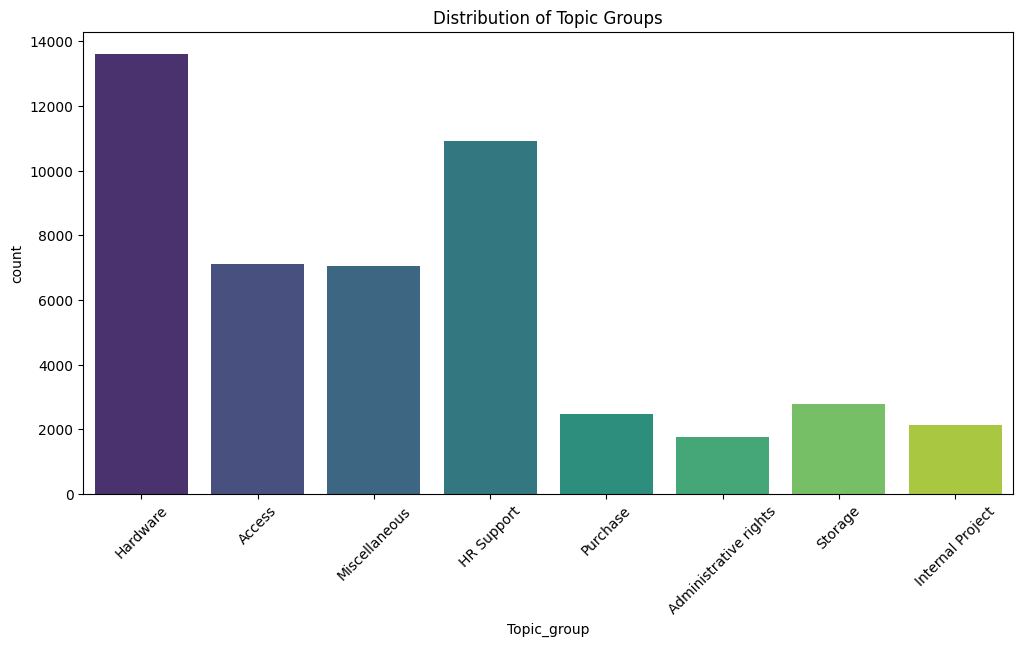

In [13]:
plt.figure(figsize=(12, 6))
sns.countplot(x=data['Topic_group'], palette='viridis')
plt.xticks(rotation=45)
plt.title('Distribution of Topic Groups')
plt.show()

#### Sentence Length Analysis

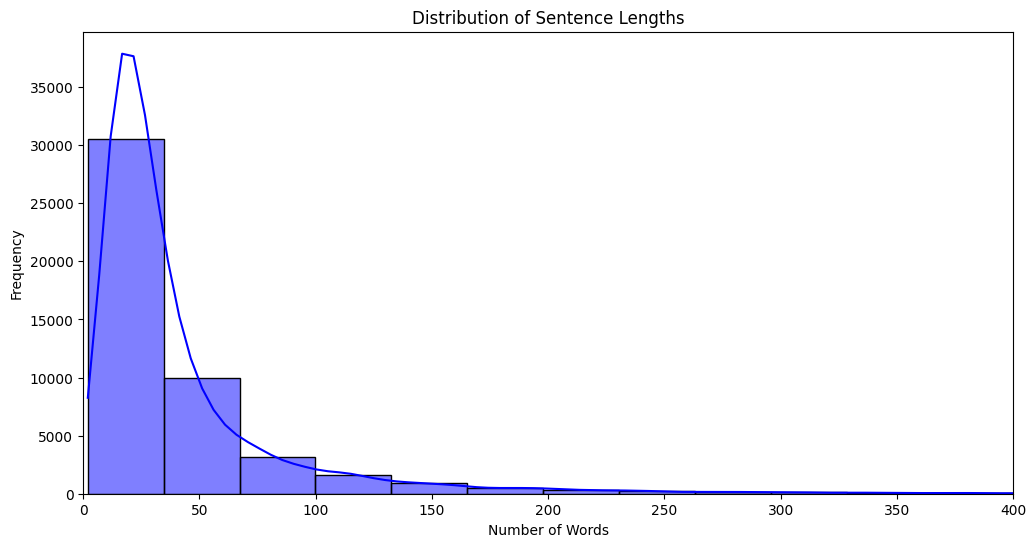

In [14]:
sen_lengths = []
for i in range(len(data)):
    sen_lengths.append(len(data['Document'][i].split()))


plt.figure(figsize=(12, 6))
sns.histplot(sen_lengths, bins=30, kde=True, color='blue')
plt.xlim(0, 400)

plt.title('Distribution of Sentence Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

#### Data spliting

In [11]:
for i in [38, 39, 40, 41, 42, 43, 44, 45]:
    x_train_emb, x_test_emb, y_train_label, y_test_label = train_test_split(
        embeddings, labels_encoded, test_size=0.2, random_state=i
    ) 

    lr_model = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
    lr_model.fit(x_train_emb, y_train_label)
    print(i)
    print(f"Train Score: {lr_model.score(x_train_emb, y_train_label)*100}")
    print(f"Test Score: {lr_model.score(x_test_emb, y_test_label)*100}")
    

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


38
Train Score: 80.9846089524158
Test Score: 79.22240802675586


C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


39
Train Score: 80.99506127675141
Test Score: 79.87040133779264


C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


...

43
Train Score: 80.95586506049283
Test Score: 79.71362876254182


C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


44
Train Score: 80.89576419556299
Test Score: 79.9435618729097


C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


45
Train Score: 80.82259792521363
Test Score: 80.7378762541806


In [15]:
x_train_emb, x_test_emb, y_train_label, y_test_label = train_test_split(
    embeddings, labels_encoded, test_size=0.2, random_state=42
) 

In [16]:
print(f"Train_split: {x_train_emb.shape}, {y_train_label.shape}\nTest_split: {x_test_emb.shape}, {y_test_label.shape}")

Train_split: (38269, 384), (38269,)
Test_split: (9568, 384), (9568,)


## **Model Build**

#### Cross Validation

In [14]:
cross_val_score(LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs'), x_train_emb, y_train_label, cv=StratifiedKFold(n_splits=5))

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\

array([0.80781291, 0.79736086, 0.79043637, 0.79396394, 0.79655037])

#### LogisticRegression

In [17]:
lr_model = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
lr_model.fit(x_train_emb, y_train_label)

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [18]:
print(f"Train Score: {lr_model.score(x_train_emb, y_train_label)*100}")
print(f"Test Score: {lr_model.score(x_test_emb, y_test_label)*100}")

Train Score: 80.92450808748596
Test Score: 79.70317725752508


#### RandomForest

In [17]:
rf = RandomForestClassifier(n_estimators=50)
rf.fit(x_train_emb, y_train_label)

RandomForestClassifier(n_estimators=50)

In [18]:
print(f"Train Score: {rf.score(x_train_emb, y_train_label)*100}")
print(f"Test Score: {rf.score(x_test_emb, y_test_label)*100}")

Train Score: 100.0
Test Score: 75.376254180602


#### DecisionTree

In [19]:
dt = DecisionTreeClassifier()
dt.fit(x_train_emb, y_train_label)

DecisionTreeClassifier()

In [20]:
print(f"Train Score: {dt.score(x_train_emb, y_train_label)*100}")
print(f"Test Score: {dt.score(x_test_emb, y_test_label)*100}")

Train Score: 100.0
Test Score: 54.02382943143813


### HyperParameter Tuning

##### *------------!More Time Consumption this process-------------*

In [21]:
# param_grid = {
#     'max_iter': [500, 1000, 1500],
#     'multi_class': ['multinomial'],
#     'solver': ['lbfgs', 'sag', 'saga']
# } 


# random_search = RandomizedSearchCV(
#     LogisticRegression(),
#     param_distributions=param_grid,
#     n_iter=10,
#     cv=StratifiedKFold(n_splits=5),
#     random_state=42,
#     n_jobs=-1
# )
# random_search.fit(x_train_emb, y_train_label)

#### Model and Encoder Save

In [19]:
# Save the best model
joblib.dump(lr_model, 'logistic_regression_model.joblib')
print("Model saved successfully.")

Model saved successfully.


In [53]:
# Save Encoder
joblib.dump(le, "label_encoder_model.joblib")

['label_encoder_model.joblib']

In [24]:
# Load the model
model = joblib.load('logistic_regression_model.joblib')

#### Evaluation

In [25]:
y_prd = model.predict(x_test_emb)
print(classification_report(y_test_label, y_prd, target_names=le.classes_))

                       precision    recall  f1-score   support

               Access       0.85      0.85      0.85      1455
Administrative rights       0.85      0.64      0.73       342
           HR Support       0.77      0.79      0.78      2107
             Hardware       0.77      0.81      0.79      2760
     Internal Project       0.89      0.77      0.83       451
        Miscellaneous       0.73      0.75      0.74      1400
             Purchase       0.93      0.86      0.90       497
              Storage       0.86      0.81      0.84       556

             accuracy                           0.80      9568
            macro avg       0.83      0.79      0.81      9568
         weighted avg       0.80      0.80      0.80      9568



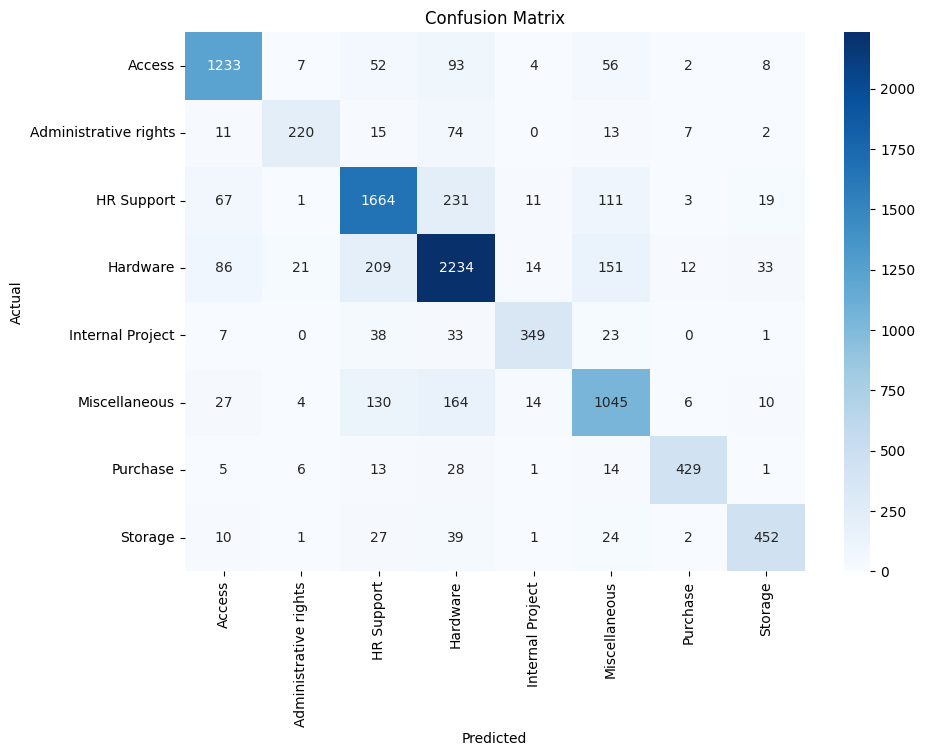

In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test_label, y_prd)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## **Final LR Model Accuracy**
### **Train:-- 80.9**
### **Test:--- 79.8**

## **Real World Prediction**

In [62]:
from sentence_transformers import SentenceTransformer
pd.reset_option('display.max_colwidth')

m_path = 'logistic_regression_model.joblib'
le_path = 'label_encoder_model.joblib'

#### Load the Model, Embed_model, Enc_model

In [67]:
def predict_ticket_category(text, model_path=None, label_en_path=None):
    label_en_model = joblib.load(label_en_path)
    model = joblib.load(model_path)
    embed_model = SentenceTransformer("all-MiniLM-L6-v2")

    text_emb = embed_model.encode([text])
    prd = model.predict(text_emb)
    return f"Predicted Category: {label_en_model.inverse_transform(prd)[0]}"


In [68]:
def sample_data(data, num_samples=5):
    for i in range(num_samples):
        sample_test = data['Document'][i]
        labels = data['Topic_group'][i]
        print(f"{sample_test} :-- {labels}")

sample_data(data, num_samples=5)

connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead :-- Hardware
work experience user work experience user hi work experience student coming next his name much appreciate him duration thank :-- Access
requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug :-- Hardware
reset passwords for external accounts re expire days hi ask help update passwords colleagues thank pm expire days importance high hi received about expiration please kindly help prolongation best regards pm expire days importance high dear expire days order change please follow steps prerequisites disable device credentials close active connected by cable machine note also follow steps detailed press ctrl alt delete same pops change item enter format enter enter newly chosen then re enter again submit displaying has changed os machine browse enter format enter gear icon top tight browser window enter enter newly chosen then 

#### **Prediction**

In [74]:
text = "connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead"
actual_label = "Hardware"

In [77]:
final_prd = predict_ticket_category(text, model_path=m_path, label_en_path=le_path)  

print(f"Actual Category: {actual_label}")
print(final_prd)

Actual Category: Hardware
Predicted Category: Hardware


In [79]:
for i in range(5):
    final_prd = predict_ticket_category(data['Document'][i], model_path=m_path, label_en_path=le_path)  

    print(i)
    print(f"Actual Category: {data['Topic_group'][i]}")
    print(final_prd)

0
Actual Category: Hardware
Predicted Category: Hardware
1
Actual Category: Access
Predicted Category: Access
2
Actual Category: Hardware
Predicted Category: Hardware
3
Actual Category: Access
Predicted Category: Access
4
Actual Category: Miscellaneous
Predicted Category: Miscellaneous


### Backend Program

In [ ]:
import joblib
from sentence_transformers import SentenceTransformer

class Backend_Program:
    def __init__(self, model_path, label_en_path):
        self.model = joblib.load(model_path)
        self.label_encoder = joblib.load(label_en_path)
        self.embed_model = SentenceTransformer("all-MiniLM-L6-v2")

    def predict_ticket_category(self, text):
        text_emb = self.embed_model.encode([text])
        prd = self.model.predict(text_emb)
        label = self.label_encoder.inverse_transform(prd)[0]
        return f"Predicted Category: {label}"

    def sample_data(self, data, num_samples=5):
        for i in range(num_samples):
            sample_test = data['Document'][i]
            labels = data['Topic_group'][i]
            print(f"{sample_test} :-- {labels}")